<a href="https://colab.research.google.com/github/Dipterocarpaceae/Dipterocarpaceae/blob/main/CobaAlurDataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
install.packages("mlbench") #Package yang memiliki dataset- BreastCancer
install.packages("caTools") #Package memiliki fungsi split yang digunakan untuk membagi dataset kita menjadi data pelatihan dan pengujian.
install.packages("caret") #Package memiliki fungsi untuk melatih dan merencanakan model
install.packages("mice") #Package berfungsi untuk menangani missing data di dataset, termasuk dengan cara delete
install.packages("e1071") #Package untuk metode SVM
install.packages("ggplot2") #Package untuk membuat plot
install.packages("downloader") #Package untuk mengunduh file dari website
install.packages("dplyr") #Package untuk fungsi manipulasi data dalam bentuk dataframe
install.packages("tidyverse") #Package untuk beberapa fungsi pemodelan
install.packages("corrplot") #Package untuk membuat plot korelasi
install.packages("corrgram")
install.packages("ROCR")
install.packages("plotly")
install.packages("PerformanceAnalytics")
install.packages("lattice")
install.packages("psych")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘bitops’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘future.apply’, ‘progressr’, ‘numDeriv’, ‘SQUAREM’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘gower’, ‘ipred’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing packa

In [4]:
library(mlbench) #Package yang memiliki dataset- BreastCancer
library(caTools) #Package memiliki fungsi split yang digunakan untuk membagi dataset kita menjadi data pelatihan dan pengujian.
library(caret) #Package memiliki fungsi untuk melatih dan merencanakan model
library(mice) #Package berfungsi untuk menangani missing data di dataset, termasuk dengan cara delete
library(e1071) #Package untuk metode SVM
library(ggplot2) #Package untuk membuat plot
library(downloader) #Package untuk mengunduh file dari website
library(dplyr) #Package untuk fungsi manipulasi data dalam bentuk dataframe
library(tidyverse) #Package untuk beberapa fungsi pemodelan
library(corrplot) #Package untuk membuat plot korelasi
library(corrgram)
library(ROCR)
library(plotly)
library(PerformanceAnalytics)
library(lattice)
library(psych)

Loading required package: ggplot2

Loading required package: lattice

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”

Attaching package: ‘mice’


The following object is masked from ‘package:stats’:

    filter


The following objects are masked from ‘package:base’:

    cbind, rbind



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ tibble  3.1.4     ✔ purrr   0.3.4
✔ tidyr   1.1.3     ✔ stringr 1.4.0
✔ readr   2.0.1     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks mice::filter(), stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()

corrplot 0.90 loaded


Attaching package: ‘corrgram’


In [5]:
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

# Membaca data
dataBC <- read.csv(url)
head(dataBC)

,X1000025,X5,X1,X1.1,X1.2,X2,X1.3,X3,X1.4,X1.5,X2.1
,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2


In [6]:
#Mengganti nama kolom
# names(dataBC) <- c("id","CellThickness", "UniformCellSize", "UniformCellShape", "Marg. Adhesion", "EpithomeCellSize", "Bare.Nuclei", "Bl.Cromatin", "NormalNucleoli","Mitoses", "diagnosis")
dataBC <- read.csv(file = url, header = FALSE,col.names = c("id","CellThickness", "UniformCellSize", "UniformCellShape", "Marg. Adhesion", "EpithomeCellSize", "Bare.Nuclei", "Bl.Cromatin", "NormalNucleoli","Mitoses", "diagnosis") )
head(dataBC)

,id,CellThickness,UniformCellSize,UniformCellShape,Marg..Adhesion,EpithomeCellSize,Bare.Nuclei,Bl.Cromatin,NormalNucleoli,Mitoses,diagnosis
,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
1,1000025,5,1,1,1,2,1,3,1,1,2
2,1002945,5,4,4,5,7,10,3,2,1,2
3,1015425,3,1,1,1,2,2,3,1,1,2
4,1016277,6,8,8,1,3,4,3,7,1,2
5,1017023,4,1,1,3,2,1,3,1,1,2
6,1017122,8,10,10,8,7,10,9,7,1,4


In [7]:
# buat atribut baru berdasarkan diagnosis
dataBC$outcome[dataBC$diagnosis == 4] = 1
dataBC$outcome[dataBC$diagnosis == 2] = 0
dataBC$outcome = as.integer(dataBC$outcome)
head(dataBC)

,id,CellThickness,UniformCellSize,UniformCellShape,Marg..Adhesion,EpithomeCellSize,Bare.Nuclei,Bl.Cromatin,NormalNucleoli,Mitoses,diagnosis,outcome
,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>
1,1000025,5,1,1,1,2,1,3,1,1,2,0
2,1002945,5,4,4,5,7,10,3,2,1,2,0
3,1015425,3,1,1,1,2,2,3,1,1,2,0
4,1016277,6,8,8,1,3,4,3,7,1,2,0
5,1017023,4,1,1,3,2,1,3,1,1,2,0
6,1017122,8,10,10,8,7,10,9,7,1,4,1


In [8]:
#Pengecekan missing data
sapply(dataBC, function(x) sum(is.na(x)))

id    CellThickness  UniformCellSize UniformCellShape 
               0                0                0                0 
  Marg..Adhesion EpithomeCellSize      Bare.Nuclei      Bl.Cromatin 
               0                0                0                0 
  NormalNucleoli          Mitoses        diagnosis          outcome 
               0                0                0                0

In [9]:
# Preprocessing, menyiapkan data untuk analisis
# Kita akan menghapus atribut/variabel ID karena tidak bermanfaat untuk klasifikasi
dataBC2 <- dataBC %>% select(-id, -Bare.Nuclei)
# dataBC2[,c(9,10)]
dataBC2$outcome[dataBC2$diagnosis==4] = 1
dataBC2$outcome[dataBC2$diagnosis==2] = 0
dataBC2$outcome = as.integer(dataBC2$outcome)
head(dataBC2)

,CellThickness,UniformCellSize,UniformCellShape,Marg..Adhesion,EpithomeCellSize,Bl.Cromatin,NormalNucleoli,Mitoses,diagnosis,outcome
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,5,1,1,1,2,3,1,1,2,0
2,5,4,4,5,7,3,2,1,2,0
3,3,1,1,1,2,3,1,1,2,0
4,6,8,8,1,3,3,7,1,2,0
5,4,1,1,3,2,3,1,1,2,0
6,8,10,10,8,7,9,7,1,4,1


In [10]:
# Menyiapkan dataset ke dalam bentuk DataFrame
mydata <- data.frame(dataBC2)
str(mydata)

'data.frame':	699 obs. of  10 variables:
 $ CellThickness   : int  5 5 3 6 4 8 1 2 2 4 ...
 $ UniformCellSize : int  1 4 1 8 1 10 1 1 1 2 ...
 $ UniformCellShape: int  1 4 1 8 1 10 1 2 1 1 ...
 $ Marg..Adhesion  : int  1 5 1 1 3 8 1 1 1 1 ...
 $ EpithomeCellSize: int  2 7 2 3 2 7 2 2 2 2 ...
 $ Bl.Cromatin     : int  3 3 3 3 3 9 3 3 1 2 ...
 $ NormalNucleoli  : int  1 2 1 7 1 7 1 1 1 1 ...
 $ Mitoses         : int  1 1 1 1 1 1 1 1 5 1 ...
 $ diagnosis       : int  2 2 2 2 2 4 2 2 2 2 ...
 $ outcome         : int  0 0 0 0 0 1 0 0 0 0 ...


In [11]:
#STATISTIK DESKRIPTIF
summary(mydata)

 CellThickness    UniformCellSize  UniformCellShape Marg..Adhesion  
 Min.   : 1.000   Min.   : 1.000   Min.   : 1.000   Min.   : 1.000  
 1st Qu.: 2.000   1st Qu.: 1.000   1st Qu.: 1.000   1st Qu.: 1.000  
 Median : 4.000   Median : 1.000   Median : 1.000   Median : 1.000  
 Mean   : 4.418   Mean   : 3.134   Mean   : 3.207   Mean   : 2.807  
 3rd Qu.: 6.000   3rd Qu.: 5.000   3rd Qu.: 5.000   3rd Qu.: 4.000  
 Max.   :10.000   Max.   :10.000   Max.   :10.000   Max.   :10.000  
 EpithomeCellSize  Bl.Cromatin     NormalNucleoli      Mitoses      
 Min.   : 1.000   Min.   : 1.000   Min.   : 1.000   Min.   : 1.000  
 1st Qu.: 2.000   1st Qu.: 2.000   1st Qu.: 1.000   1st Qu.: 1.000  
 Median : 2.000   Median : 3.000   Median : 1.000   Median : 1.000  
 Mean   : 3.216   Mean   : 3.438   Mean   : 2.867   Mean   : 1.589  
 3rd Qu.: 4.000   3rd Qu.: 5.000   3rd Qu.: 4.000   3rd Qu.: 1.000  
 Max.   :10.000   Max.   :10.000   Max.   :10.000   Max.   :10.000  
   diagnosis       outcome      
 

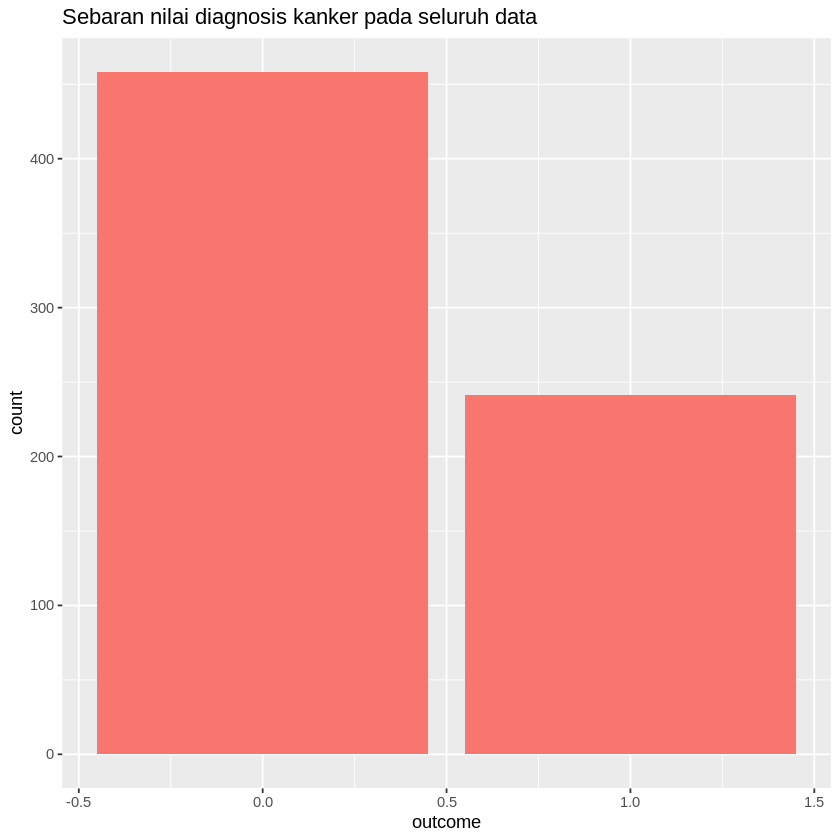

In [12]:
#PERIKSA APAKAH DATA IMBALANCE
ggplot(mydata, aes(x = outcome)) + 
geom_bar(aes(fill = "blue")) + 
ggtitle("Sebaran nilai diagnosis kanker pada seluruh data") + 
theme(legend.position = "none")

Di sini terlihat bahwa data kita imbalance, yaitu pasien yang sehat, atau kankernya jinak (kode 0) jumlahnya hampir 2x lipat dari pasien yang perlu dirawat yaitu kankernya ganas (kode 1). Karena False Negatif di sini lebih penting untuk dihindari, dengan kondisi imbalance ini, artinya selain akurasi, kita akan sangat memperhatikan precision-nya pada saat evaluasi model. Selain itu, karena imbalance, artinya akurasi saja tidak cukup. Kita perlu melihat evaluasi tertimbangnya, yaitu dalam bentuk F1-score atau Kappa statistics.

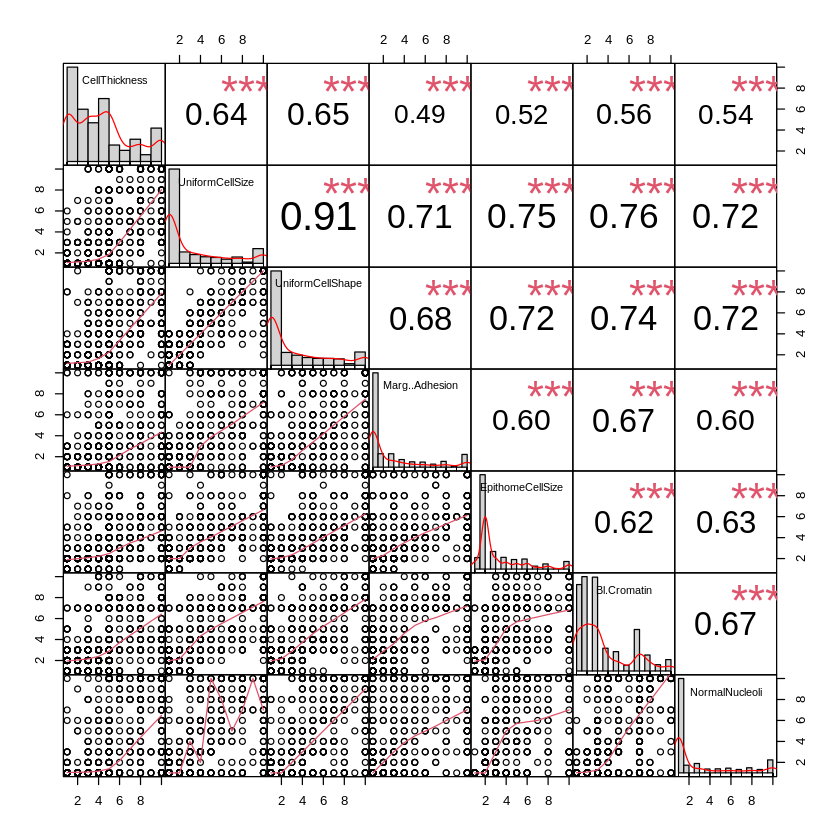

In [13]:
#PERIKSA KORELASI ANTAR ATRIBUT
chart.Correlation(mydata[, c(1:7)], 
histogram=T, col='grey10', pch=1, main="Cancer Means")

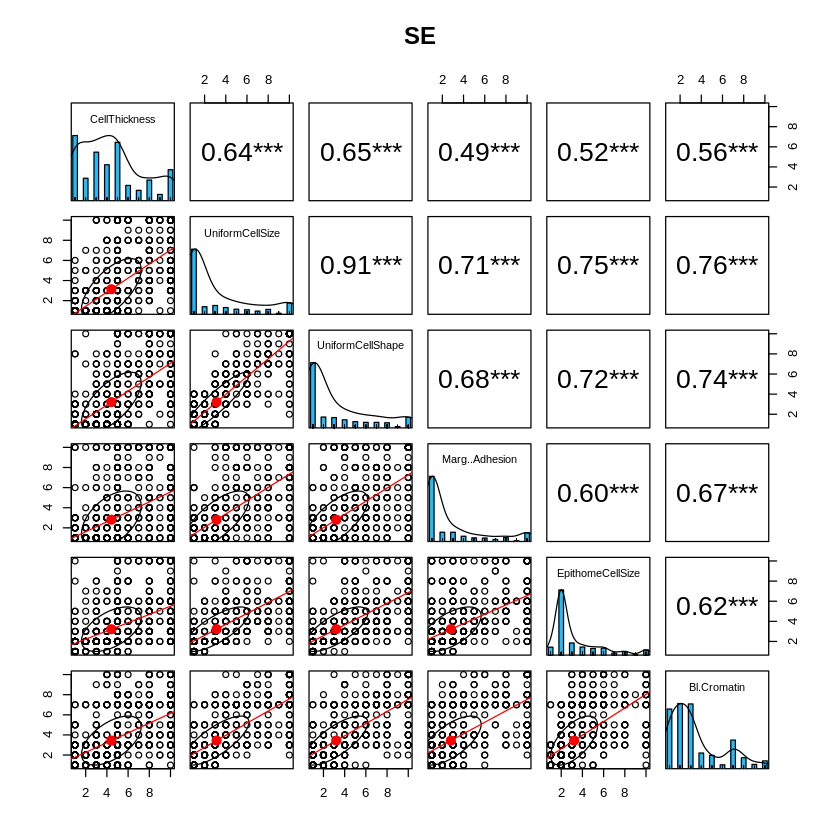

In [16]:
pairs.panels(mydata[, c(1:6)], method = "pearson",
hist.col = "#1fbbfa", density=T, ellipses=T, show.points=T,
pch=1, lm=T, cex.cor=1, smoother=F, stars=T, main="SE")

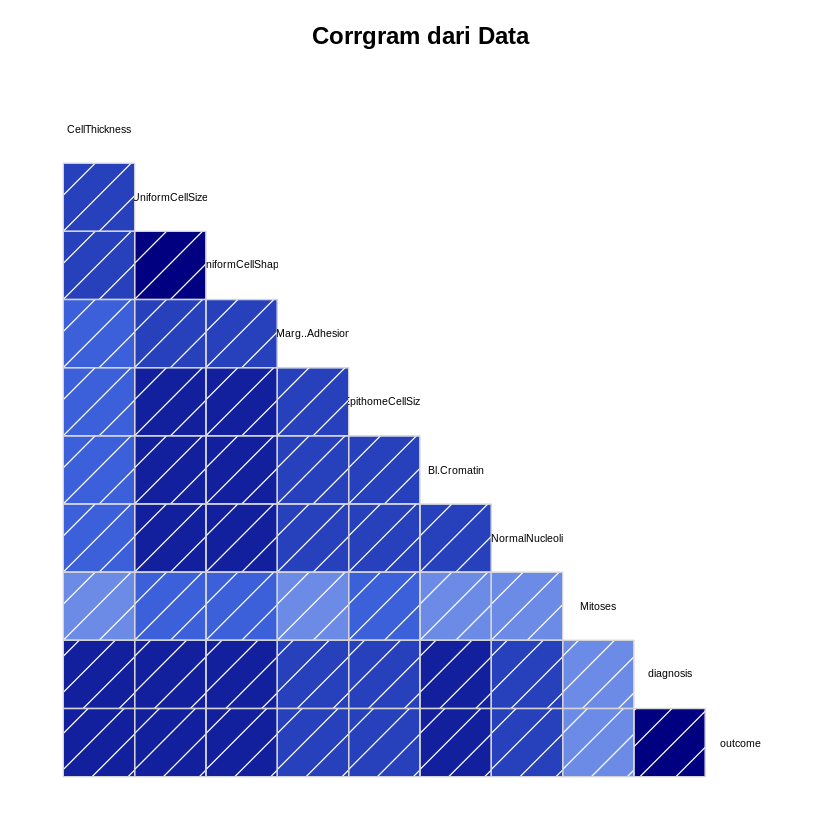

In [17]:
corrgram(mydata, order=NULL, lower.panel = panel.shade, upper.panel=NULL,
text.panel=panel.txt, main="Corrgram dari Data")

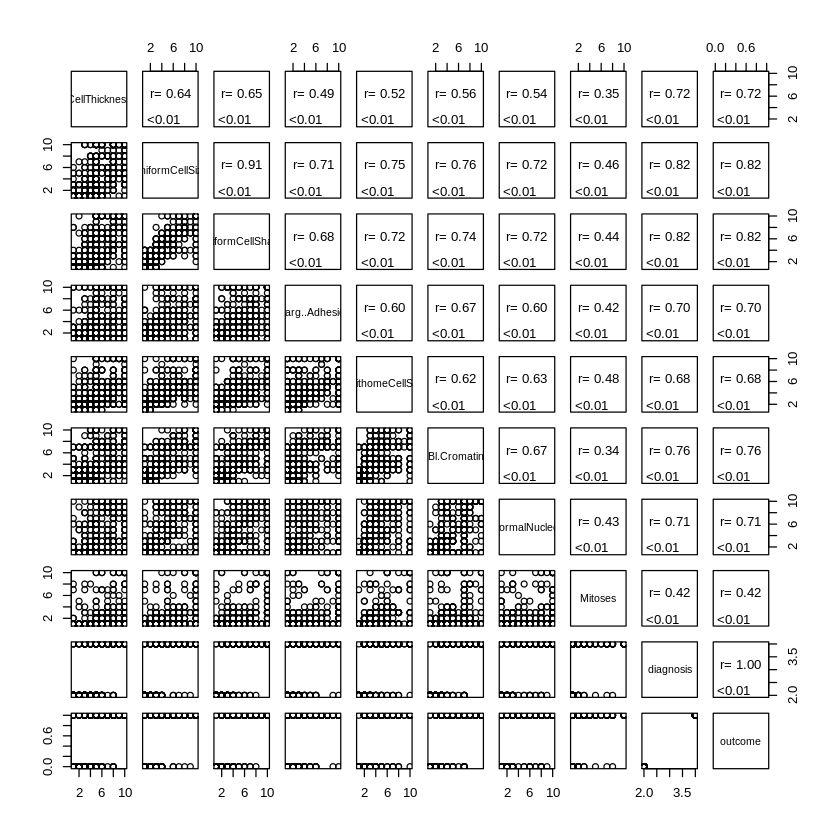

In [19]:
# memeriksa korelasi liniernya (tidak wajib)
panel.cor <- function(x, y, digits = 2, cex.cor, ...)
{
  usr <- par("usr"); on.exit(par(usr))
  par(usr = c(0, 1, 0, 1))
  # correlation coefficient
  r <- cor(x, y)
  txt <- format(c(r, 0.123456789), digits = digits)[1]
  txt <- paste("r= ", txt, sep = "")
  text(0.5, 0.6, txt)
  
  # p-value calculation
  p <- cor.test(x, y)$p.value
  txt2 <- format(c(p, 0.123456789), digits = digits)[1]
  txt2 <- paste("p= ", txt2, sep = "")
  if(p<0.01) txt2 <- paste("p= ", "<0.01", sep = "")
  text(0.2, 0.1, txt2)
}
pairs(mydata, upper.panel = panel.cor)

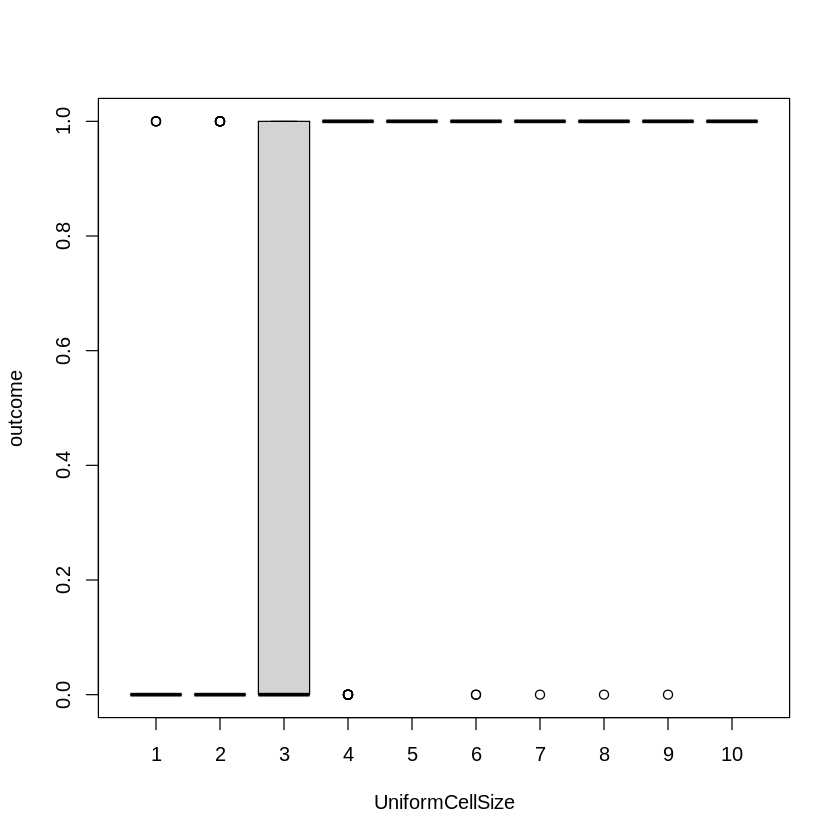

In [20]:
# Pemeriksaan sebaran nilai data pada tiap atribut/variabel untuk tiap-tiap kelas
# Dengan melihat apakah ada perbedaan sebaran nilai yang mencolok,
# kita bisa mendapatkan gambaran, atribut/variabel manakah yang
# secara umum kita duga bisa menjadi pembeda utama antara 2 kelas

boxplot(outcome~UniformCellSize, data = mydata)

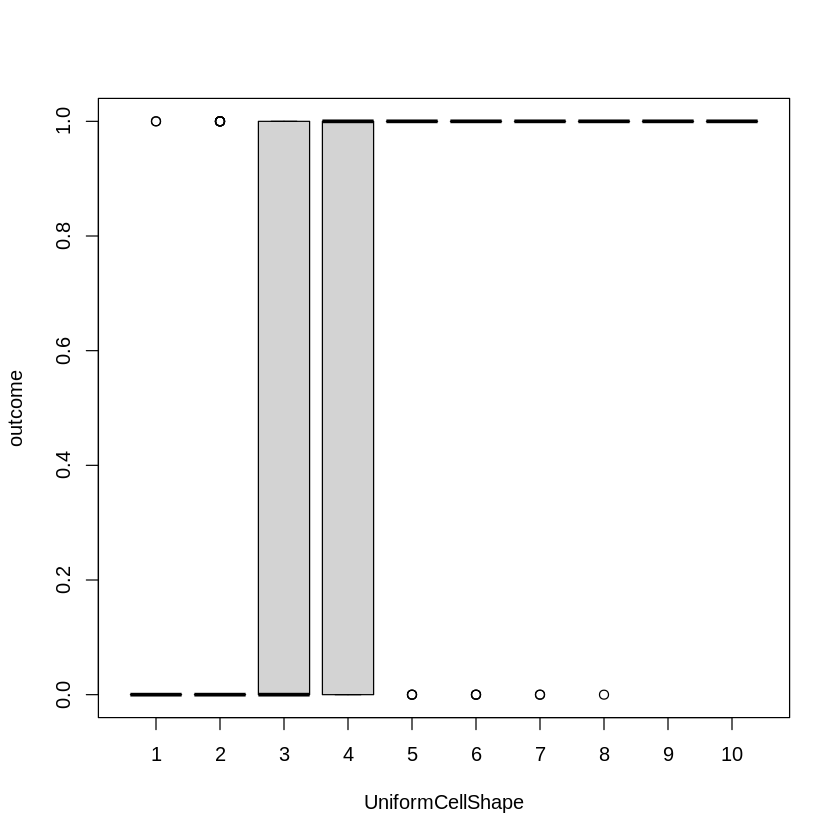

In [21]:
boxplot(outcome~UniformCellShape, data = mydata)

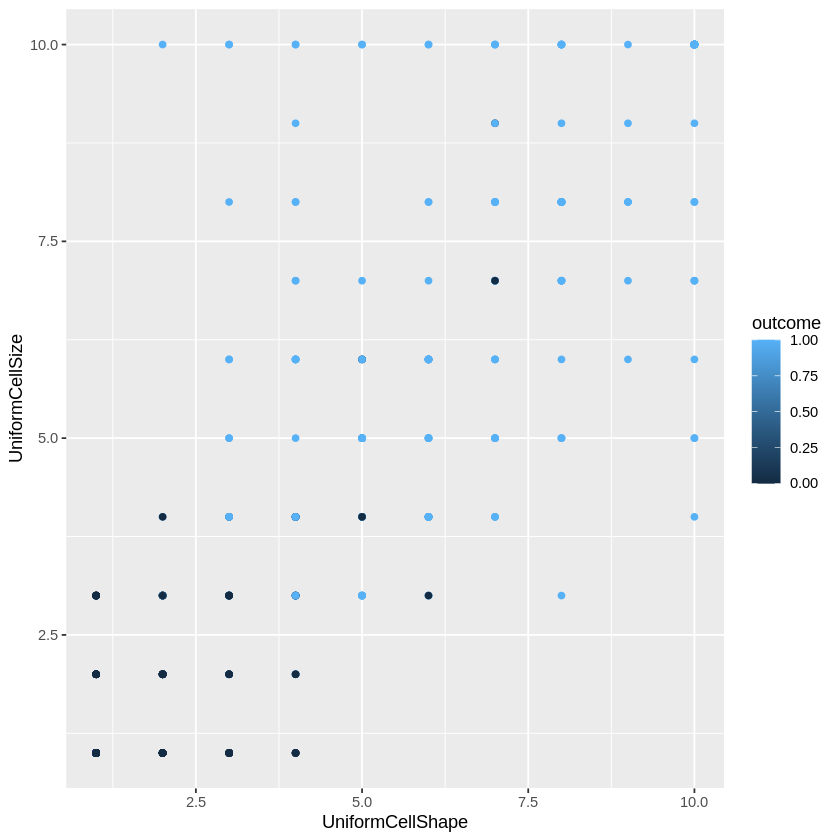

In [22]:
qplot(UniformCellShape, UniformCellSize, data = mydata, color=outcome)

In [23]:
# Membagi data untuk training set dan testing set
# Pada kasus ini, gunakan 50% data latih
# Jangan lupa memasang set.seed agar pembagian secara random ini bisa direproduksi lagi.
# Pada package caTools disediakan fitur sample.split()

set.seed(1229)
Split <- sample.split(mydata$outcome, SplitRatio = 0.5)
training <- subset(mydata, Split == T)
testing <- subset(mydata, Split = F)
head(training)

,CellThickness,UniformCellSize,UniformCellShape,Marg..Adhesion,EpithomeCellSize,Bl.Cromatin,NormalNucleoli,Mitoses,diagnosis,outcome
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,5,1,1,1,2,3,1,1,2,0
2,5,4,4,5,7,3,2,1,2,0
4,6,8,8,1,3,3,7,1,2,0
6,8,10,10,8,7,9,7,1,4,1
7,1,1,1,1,2,3,1,1,2,0
10,4,2,1,1,2,2,1,1,2,0


In [24]:
head(testing)

,CellThickness,UniformCellSize,UniformCellShape,Marg..Adhesion,EpithomeCellSize,Bl.Cromatin,NormalNucleoli,Mitoses,diagnosis,outcome
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,5,1,1,1,2,3,1,1,2,0
2,5,4,4,5,7,3,2,1,2,0
3,3,1,1,1,2,3,1,1,2,0
4,6,8,8,1,3,3,7,1,2,0
5,4,1,1,3,2,3,1,1,2,0
6,8,10,10,8,7,9,7,1,4,1


In [ ]:
#Bangun model SVM

Klasifikasi observasi pada R menggunakan SVM membutuhkan library e1071. Pada e1071 didefinisikan fungsi-fungsi standar yang dapat digunakan untuk membentuk support vector, memprediksi klas untuk amatan baru, serta melakukan fine tunning untuk parameter-parameter SVM yang dihasilkan.

In [25]:
svm_model <- svm(outcome~., data = training, type = "C-classification", kernel = "radial")
summary(svm_model)


Call:
svm(formula = outcome ~ ., data = training, type = "C-classification", 
    kernel = "radial")


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  55

 ( 13 42 )


Number of Classes:  2 

Levels: 
 0 1




Terbentuk ada sebesar 20 support vector dari keseluruhan observasi pada data latih (training set). Kernel SVM yang digunakan adalah kernel radial yang berguna untuk mengklasifikasikan observasi.

Visualisasi Model

Untuk melihat visualisasi model SVM kita hanya bisa melihatnya dengan memeriksa kombinasi dari dua atribut, contoh di sini kita akan melihat dari atribut UniformCellSize dan UniformCellShape

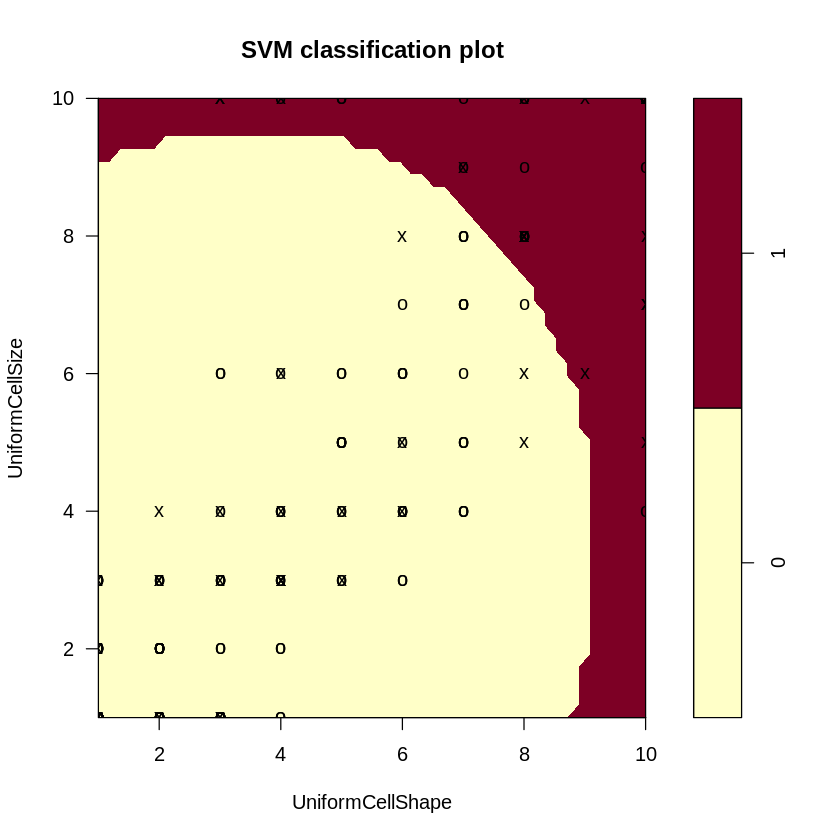

In [26]:
plot(svm_model, training, UniformCellSize ~ UniformCellShape)

PREDIKSI DAN EVALUASI MODEL

Pada tahap ini kita akan memprediksi nilai outcome label kanker pada data training

In [27]:
Prediksi <- predict(svm_model, newdata = training)
Hasil <- data.frame(training$outcome, Prediksi)
colnames(Hasil) <- c("Aktual", "Prediksi")
head(Hasil, n =5 )

,Aktual,Prediksi
,<int>,<fct>
1,0,0
2,0,0
4,0,0
6,1,1
7,0,0


Evaluasi model pada training set kita lakukan dengan melihat confusion matrix nya

In [28]:
training_outcome <- factor(training$outcome)
confusionMatrix(Prediksi, training_outcome)

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 229   0
         1   0 120
                                     
               Accuracy : 1          
                 95% CI : (0.9895, 1)
    No Information Rate : 0.6562     
    P-Value [Acc > NIR] : < 2.2e-16  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         
                                     
            Sensitivity : 1.0000     
            Specificity : 1.0000     
         Pos Pred Value : 1.0000     
         Neg Pred Value : 1.0000     
             Prevalence : 0.6562     
         Detection Rate : 0.6562     
   Detection Prevalence : 0.6562     
      Balanced Accuracy : 1.0000     
                                     
       'Positive' Class : 0          
                                     

Pada model SVM yang kita bangun berdasarkan data training, akurasi yang dihasilkan adalah sebesar 100% sangat bagus, namun perlu kita cek bagaimana performanya pada data testing.

**KLASIFIKASI PADA DATA TESTING**

Kita akan menerapkan model yang telah dibangun ke data uji untuk melihat bagaimanakah klasifikasi dari model. Tahap ini bertujuan untuk melihat Bagaimanakah keakurasian prediksi dan confusion matrix pada data uji.

In [29]:
Prediksitest <- predict(svm_model, newdata = testing)
Hasil.Uji <- data.frame(testing$outcome, Prediksitest)
colnames(Hasil.Uji) = c("Aktual", "Prediksi")
head(Hasil.Uji, n = 5)

,Aktual,Prediksi
,<int>,<fct>
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0


In [30]:
testing_outcome <- factor(testing$outcome)
confusionMatrix(Prediksitest, testing_outcome)

Confusion Matrix and Statistics

          Reference
Prediction   0   1
         0 458   0
         1   0 241
                                     
               Accuracy : 1          
                 95% CI : (0.9947, 1)
    No Information Rate : 0.6552     
    P-Value [Acc > NIR] : < 2.2e-16  
                                     
                  Kappa : 1          
                                     
 Mcnemar's Test P-Value : NA         
                                     
            Sensitivity : 1.0000     
            Specificity : 1.0000     
         Pos Pred Value : 1.0000     
         Neg Pred Value : 1.0000     
             Prevalence : 0.6552     
         Detection Rate : 0.6552     
   Detection Prevalence : 0.6552     
      Balanced Accuracy : 1.0000     
                                     
       'Positive' Class : 0          
                                     

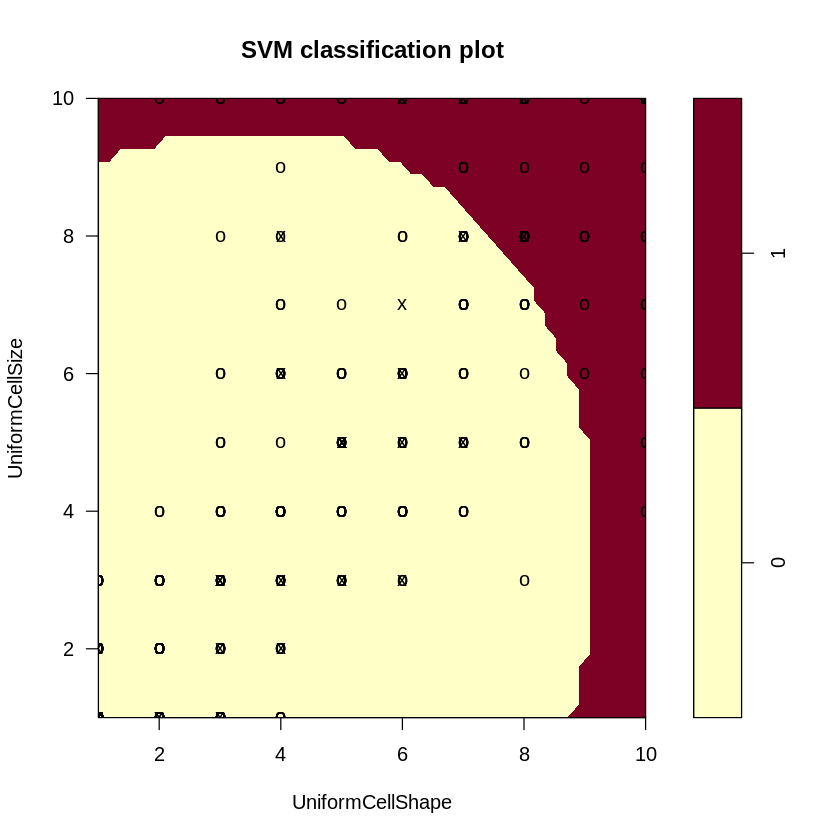

In [31]:
plot(svm_model, testing, UniformCellSize~UniformCellShape)

Nilai akurasi yang dihasilkan adalah 100%, kita sangat beruntung di sini. Namun, secara umum penting untuk dilakukan melakukan pemilihan parameter model SVM yang lebih tepat, di antaranya yaitu pemilihan kernel yang tepat.

**Pemilihan parameter terbaik model SVM dengan GridSearchCV**

Terdapat beberapa pilihan kernel pada SVM, yaitu linear, gaussian (radial basis function/RBF), polynomial, sigmoid, ataupun kita definisikan sendiri. Perhatikan contoh berikut bagaimana pengaruh pemilihan kernel pada klasifikasi untuk contoh kasus klasifikasi pada dataset lain, yaitu bunga Iris.

Kita akan melakukan tuning parameter SVM dengan metode GridSearch cross validation (GridSearchCV) untuk mendapatkan parameter model terbaik. Package e1071 sudah menyediakan fitur tuning parameter ini dengan GridSearchCV. GridSearchCV akan menjalankan perulangan yang sama dengan teknik cross validation untuk menemukan kombinasi parameter terbaik. Setelah memiliki kombinasi terbaik, lalu dilakukan running pada semua data latih untuk membangun satu model baru menggunakan pengaturan kombinasi parameter terbaik. Salah satu hal menarik tentang GridSearchCV adalah peranannya sebagai meta-classifier. GridSearchCV akan mengambil model yang dipakai sebagai classifier, misalnya SVM, dan membuat classifier baru, yang berperilaku persis sama - dalam hal ini, seperti classifier kita sebelumnya.